# Cooldown 2
### Implanted CaF2, Unannealed in Confocal setup with Mango

In [ ]:
## General purpose
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.axes as axes
import scipy as sp
import scipy.fft
import drivers.spectroscopyHelpers as sh
import drivers3.laserHelpers as lh
import scipy.optimize as sp
import os
import time
import datetime
import scipy.signal
import matplotlib.colors as cls
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
import importlib
import pprint
from tqdm import tqdm
import glob
import re
import scipy.stats
import qcodes as qc
import sys
import qil_Visa.visa as visa
import pyvisa

In [2]:
# Import functions!!
import drivers.spectroscopyHelpers as sh
import drivers.pulse_sequence as beeps
import drivers.proHelpers as proHelp
from drivers.dlccontrol import dlccontrol as ctrl
import drivers3.laserHelpers as lhzz
import drivers.experimentFunctions as exhp

In [9]:
### Toptica Laser
from toptica.lasersdk.dlcpro.v2_2_0 import DLCpro, NetworkConnection  
laserIP = '10.196.50.22'

### Wavemeter
from qil_WS6wavemeter import TCP_Wavemeter

try:
    wm = TCP_Wavemeter.cWS6WavemeterClient(host='qil-wario')
    print("Wavemeter frequency: ", wm.readFrequency())
except KeyError:
    print("Key error returned - wavemeter probably not seeing enough light.")

### Stahl power supply
from qcodes.instrument_drivers.rigol import DP832
from qcodes.instrument_drivers.stahl import Stahl
stahl = Stahl("stahl-9", "ASRL4")       
detectorOut = stahl.channel8

### American magnetics power supply
from qcodes.instrument_drivers.american_magnetics.AMI430_visa import AMI430 

### Moku AWG
import moku

### For the Moku Pro
from moku.instruments import ArbitraryWaveformGenerator
mokuIP = '10.196.50.45' # Sydnet6 IP for Moku Pro
awg = ArbitraryWaveformGenerator(mokuIP, force_connect=True, persist_state=True, read_timeout=30)

### For Bluey
import json 
import requests

### Attocube
import qil_attocube
amc = qil_attocube.Device('10.196.50.26')
amc.connect()
axis = 0 # Corresponds to axis 1 on the AMC300 controller

# ### Keithley DMM
# import qcodes.instrument_drivers.tektronix.Keithley_6500 as dmm6500
# dmm = dmm6500.Keithley_6500('dmm','TCPIP::10.196.50.27::INSTR')

### Rigol oscilloscope 
from qil_Rigol.rigol import cRigol 
scope = cRigol('10.196.50.21') # IP address of Rigol MSO5104 on the gantry is: 10.196.50.21. verify connection here.

### Swabian timetagger
import TimeTagger
tt = TimeTagger.createTimeTagger()

# Setting up time-tagger histogram channel
# Parameters taken from 20251015 flashy country.ipynb 
ps = 1e12 # [ps/s] - picoseconds per second. As usual I try to frame variables in SI units, but Swabian is in picoseconds. :((
binwidth = 500e-9 * ps  # 0.1 ms, in picoseconds - [s] * [ps/s]
n_bins = 80 # number of bins

hist = TimeTagger.Histogram(tagger=tt, start_channel=2, click_channel=1, binwidth=binwidth, n_bins = n_bins)
tt.setTriggerLevel(2, 0.25)      # starts channel trigger level = 250 mV (signal is 500 mV)
tt.setTriggerLevel(1, 0.03)      # click channel trigger level = 33 mV
tt.setDeadtime(1, 30e-9 * ps)

Importing Functions
Key error returned - wavemeter probably not seeing enough light.
Connected to: Stahl HV (serial:177, firmware:None) in 0.02s


c:\Users\Waluigi\miniconda3\envs\qcodes\lib\site-packages\qcodes\instrument\instrument_base.py:617: UserWarning: Changed stahl-9 to stahl_9 for instrument identifier
  warnings.warn(f"Changed {name} to {new_name} for instrument identifier")


cVisa Init
Connected to RIGOL TECHNOLOGIES,MSO5104,MS5A234906950,00.01.03.00.03
 succesfully 


29999

In [11]:
TimeTagger.freeTimeTagger(tt)
del tt

# Setting things up

### SNSPD Initialisation

In [16]:
exhp.all_on(awg, snspd = True, plotting = False)

In [17]:
exhp.reset_detector(detectorOut, 0)

0

In [4]:
exhp.set_up_echo_SNSPD(awg, 0, 1e3, 1, countFor = 50e3, switchPreDelay = 0, plotting = False)

In [14]:
bias = -0.8
exhp.reset_detector(detectorOut, bias, sleepTime = 0.1)

-0.8

In [19]:
currentCurrent = exhp.get_detector_current(dmm)*1e6
print(f'{currentCurrent} uA')

-0.0173339 uA


In [7]:
lhzz.get_piezo_amplitude(laserIP)

0.0

### Laser Initialisation

In [8]:
# Set frequency/wavelength to A site Z1 -> Y2
c = 299792458  # m/s
ASiteFreq = 197912 * 1e9 # THz
ASiteWavelenghth = c/ASiteFreq # m

In [9]:
lhzz.turn_laser_on(laserIP)

Laser is on


In [10]:
lhzz.set_laser_wavelength(laserIP, ASiteWavelenghth*1e9) 

Wavelength now set to 1514.776557257771


In [61]:
lhzz.turn_laser_off(laserIP)

Laser is off


# 24/10 (attempted) Attocube Alignment Sequence
2 main options:
1. Step and count (accounting for unreliable sensor drift)
2. Heuristic tuning with SNSPD counts and/or reflection, using attocube command GUI

### Setting up da Attocube

In [176]:
# Attocube initialisation
print(f'Position now: {amc.move.getPosition(axis)} nm = {amc.move.getPosition(axis)/1e3} um')

Position now: 2106009.762 nm = 2105.491062 um


In [174]:
amc.move.setNSteps(axis = 0, backward = False, step = 500)

In [177]:
numSteps = 6000
stepSize = 20
steps = np.arange(0, numSteps, stepSize)
waitTime = 1 # s - Wait time between step and acquisition, for 1000Hz step
intTime = 1 # s - Integration time

steps

array([   0,   20,   40,   60,   80,  100,  120,  140,  160,  180,  200,
        220,  240,  260,  280,  300,  320,  340,  360,  380,  400,  420,
        440,  460,  480,  500,  520,  540,  560,  580,  600,  620,  640,
        660,  680,  700,  720,  740,  760,  780,  800,  820,  840,  860,
        880,  900,  920,  940,  960,  980, 1000, 1020, 1040, 1060, 1080,
       1100, 1120, 1140, 1160, 1180, 1200, 1220, 1240, 1260, 1280, 1300,
       1320, 1340, 1360, 1380, 1400, 1420, 1440, 1460, 1480, 1500, 1520,
       1540, 1560, 1580, 1600, 1620, 1640, 1660, 1680, 1700, 1720, 1740,
       1760, 1780, 1800, 1820, 1840, 1860, 1880, 1900, 1920, 1940, 1960,
       1980, 2000, 2020, 2040, 2060, 2080, 2100, 2120, 2140, 2160, 2180,
       2200, 2220, 2240, 2260, 2280, 2300, 2320, 2340, 2360, 2380, 2400,
       2420, 2440, 2460, 2480, 2500, 2520, 2540, 2560, 2580, 2600, 2620,
       2640, 2660, 2680, 2700, 2720, 2740, 2760, 2780, 2800, 2820, 2840,
       2860, 2880, 2900, 2920, 2940, 2960, 2980, 30

In [178]:
lhzz.is_laser_on(laserIP)

True

In [144]:
lhzz.get_laser_wavelength(laserIP) 


1514.677

In [146]:
exhp.get_laser_frequency(wm, 10)

197.9119094848633

In [147]:
# Roughly aim to centre at 3260 um - where we think surface is close to 
intTime = 1 # s
bias = -0.82 # V

stepVsCounts = np.zeros([len(steps), 3]) # Initialise data storage for N trials [# steps, position, counts]
stepVsCounts[:, 0] = steps

for i in tqdm(range(len(steps)), desc = 'Buzzing and counting...'):
    # Set SNSPD to 0 
    exhp.reset_detector(detectorOut, 0)

    # 5 steps in forward direction and wait for T1
    amc.move.setNSteps(axis = 0, backward = False, step = stepSize)
    time.sleep(waitTime)

    # (Ideally) measure drift over time interval and take mean but measure single position point for now
    positionAfter = amc.move.getPosition(axis)
    stepVsCounts[i, 1] = positionAfter

    # Start SNSPD and integrate for 2s
    exhp.reset_detector(detectorOut, bias, sleepTime = 0.1)
    data, times = exhp.getHistDataWrapped(hist, intTime = intTime)      

    counts = np.sum(data)
    stepVsCounts[i, 2] = counts

steps = stepVsCounts[:, 0]
position = stepVsCounts[:, 1]
counts = stepVsCounts[:, 2]

Buzzing and counting...: 100%|██████████| 120/120 [05:27<00:00,  2.73s/it]


In [151]:
np.max(counts)

np.float64(4.0)

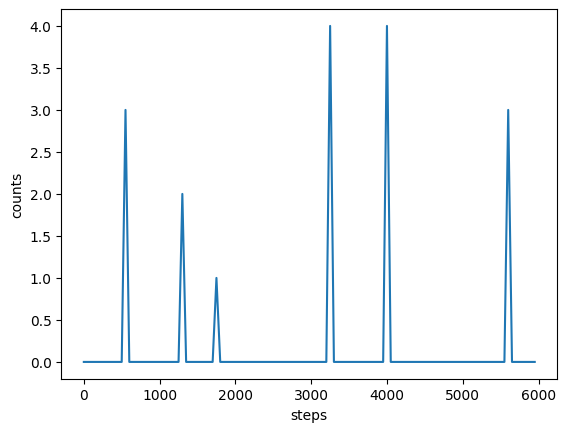

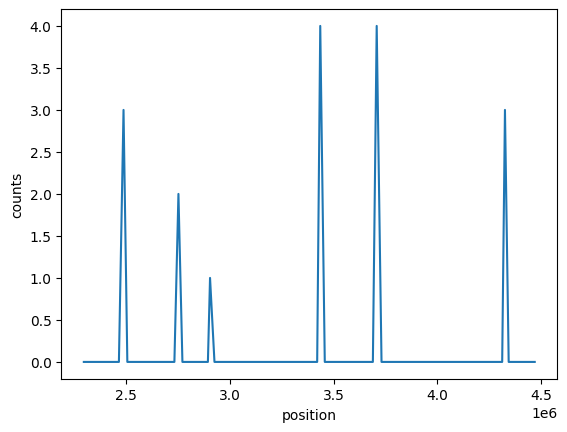

In [148]:
plt.plot(steps, counts)
plt.xlabel('steps')
plt.ylabel('counts')
plt.show()

plt.plot(position, counts)
plt.xlabel('position')
plt.ylabel('counts')
plt.show()

# 08/12 Attocube Alignment at RT
Readout using Rigol

In [13]:
numSteps = 8000 # Number of steps for traverse
stepSize = 50
steps = np.arange(0, numSteps, stepSize)
# waitTime = 1 # s - Wait time between step and acquisition, for 1000Hz step
# intTime = 1 # s - Integration time

steps

array([   0,   50,  100,  150,  200,  250,  300,  350,  400,  450,  500,
        550,  600,  650,  700,  750,  800,  850,  900,  950, 1000, 1050,
       1100, 1150, 1200, 1250, 1300, 1350, 1400, 1450, 1500, 1550, 1600,
       1650, 1700, 1750, 1800, 1850, 1900, 1950, 2000, 2050, 2100, 2150,
       2200, 2250, 2300, 2350, 2400, 2450, 2500, 2550, 2600, 2650, 2700,
       2750, 2800, 2850, 2900, 2950, 3000, 3050, 3100, 3150, 3200, 3250,
       3300, 3350, 3400, 3450, 3500, 3550, 3600, 3650, 3700, 3750, 3800,
       3850, 3900, 3950, 4000, 4050, 4100, 4150, 4200, 4250, 4300, 4350,
       4400, 4450, 4500, 4550, 4600, 4650, 4700, 4750, 4800, 4850, 4900,
       4950, 5000, 5050, 5100, 5150, 5200, 5250, 5300, 5350, 5400, 5450,
       5500, 5550, 5600, 5650, 5700, 5750, 5800, 5850, 5900, 5950, 6000,
       6050, 6100, 6150, 6200, 6250, 6300, 6350, 6400, 6450, 6500, 6550,
       6600, 6650, 6700, 6750, 6800, 6850, 6900, 6950, 7000, 7050, 7100,
       7150, 7200, 7250, 7300, 7350, 7400, 7450, 75

In [12]:
from qil_Rigol.rigol import cRigol

osc = cRigol('10.196.50.21') # IP address of Rigol MSO5104 is: 10.196.50.21. verify connection here.

cVisa Init
Connected to RIGOL TECHNOLOGIES,MSO5104,MS5A234906950,00.01.03.00.03
 succesfully 


In [14]:
# test readout and set the averages
osc.send(":ACQ:AVER 8")

# read the averages
print("Averages", osc.recieve(":ACQ:AVERages?"))

# most of Acquire actually has a function
osc.setAcquire(Averages = 8)

Averages 16

Averages set to :  16



In [15]:
# Rigol parameters - sweeptime, trigger, offset, scale
sweepTime = 1
osc.setTimebase(hrefMode="TRIG", mainOffset = sweepTime/2, mainScale = sweepTime/(1))
osc.edgeTrigger(sweep="NORM", source = 1, edge = "POS", level = 200) # how does 'level' scale?

Main offset set to :  5.000000E-1

Main scale set to :  1.000000E0

Href mode set to :  TRIG

{'mode': 'EDGE', 'sweep': 'NORM'}


## Attempt at spectrum around A site

Step size: 0.01 nm ~ 1.31 GHz
Estimated time for this many measurements: 0.33 hrs


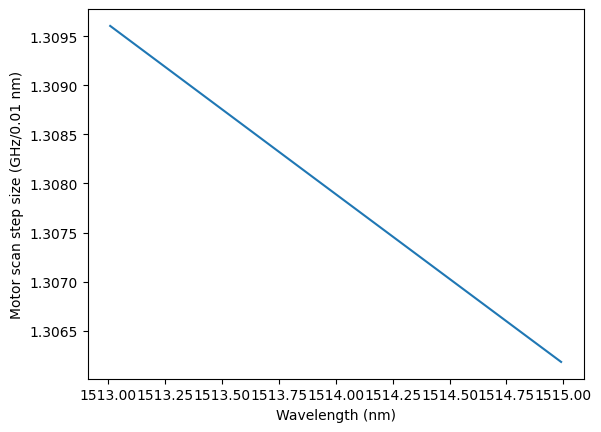

198.14438730998015 197.88411672684137


In [51]:
# Calculating the appropriate motor scan steps
c = 2.99792458e8 # [m/s]
stepSize = 0.01e-9 # [m] 0.001 nm minimum
topticaRange = np.array([1513, 1515])*1e-9 # [m]
topticaWavelengths = np.arange(topticaRange[0], topticaRange[1], stepSize)

freqRange = c/topticaWavelengths
freqSteps = freqRange/len(topticaWavelengths)

freqstepSizes = []
for i in range(len(freqSteps) - 1):
    freqstepSizes.append(np.abs(freqRange[i+1] - freqRange[i])/1e9)
print(fr'Step size: {stepSize * 1e9} nm ~ {np.mean(freqstepSizes) :.2f} GHz')

# Time estimates
numMeasurementsPerWL = 1                
intTime = 6 # [s]
wait = 0.5
print("Estimated time for this many measurements:", 
      np.round(len(topticaWavelengths) * numMeasurementsPerWL * intTime / 60 / 60, 2),         # [# steps] * [s of integration] * [# measurements] * [mins/s] * [hrs/min]
      "hrs")

plt.plot(topticaWavelengths[1:]*1e9, -np.diff(freqRange)/1e9)
plt.ylabel(f"Motor scan step size (GHz/{stepSize * 1e9} nm)")
plt.xlabel("Wavelength (nm)")
plt.show()

print(freqRange[0]/1e12, freqRange[-1]/1e12)

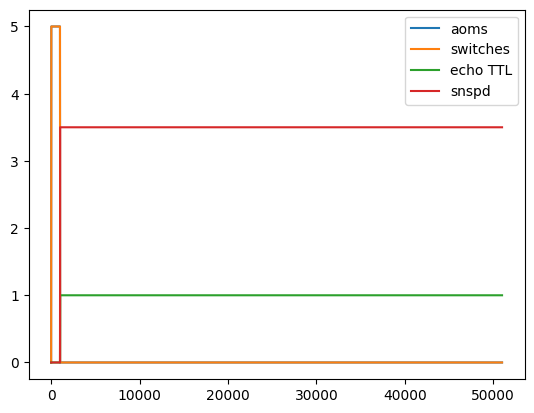

In [5]:
# Excite for 1ms; count for 50ms
exhp.set_up_echo_SNSPD(awg, 0, 1e3, 1, countFor = 50e3, switchPreDelay = 0, plotting = True)
exhp.set_deadcycles(awg, 2, channels = [1, 2, 3, 4])

In [6]:
exhp.set_up_echo_SNSPD(awg, 0, 1e3, 1, countFor = 50e3, switchPreDelay = 0, plotting = False)

In [14]:
# Set savepaths
dateString = time.strftime('%Y-%m-%d')

pathData  = f'data/'+ dateString +f'/confocal_piezo_scan/'
pathPlots = f'plots/'+ dateString +f'/confocal_piezo_scan/'
# os.makedirs(pathData, exist_ok = True)
# os.makedirs(pathPlots, exist_ok = True)

In [8]:
## 1513 - 1515 nm 
topticaRange = np.array([1513, 1515])*1e-9 # [m]
stepSize = 0.01e-9 # [m] 0.001 nm minimum
topticaWavelengths = np.arange(topticaRange[0], topticaRange[1], stepSize)

In [15]:
# Start sweep
# with tqdm(total = len(topticaWavelengths), desc = f'Current wavelength: {wavelength * 1e9} nm') as pbar:
try:
    for wavelength in topticaWavelengths:

        # Set laser frequency
        lhzz.set_laser_wavelength(laserIP, wavelength*1e9)
        
        # Collection parameters
        intTime = 6 # [s]
        bias = -0.82
        
        time.sleep(0.1)
        freq = exhp.get_laser_frequency(wm, 10) # [THz]
        exhp.reset_detector(bias, sleepTime = 0.01)
        
        data, times = exhp.getHistDataWrapped(intTime = intTime)      
        dataAndTime = np.array([times, data])

        # Save data
        now = datetime.datetime.now()
        filename = now.strftime("%Y-%m-%d %H-%M-%S") + "_freq_" + str(np.round(freq*1e3, 5)) +"_GHz_wl_" + str(np.round(wl*1e9, 4)) + "_nm"
        np.savetxt(pathData + filename + ".csv", dataAndTime, delimiter = ",")

        # Plot data
        fig, ax = plt.subplots()
        ax.plot(times*1e3, data)
        ax.set_xlabel("Time (ms)")
        ax.set_ylabel(f"Counts ({int} s integration)")
        ax.set_title(str(np.round(freq*1e3, 3)) +" GHz" + str(np.round(wl*1e9, 4)) + "_nm")
        fig.savefig(pathPlots + filename + ".png")
        fig.savefig(pathPlots + filename + ".eps")
        plt.close(fig)

        # Completed wavelength
        print(f'Completed wavelength: {wavelength * 1e9} nm')

    print("Finished succesfully!")
    print("Now turning laser off...")
    lhzz.turn_laser_off(laserIP)
    print("Laser off")

except Exception as error:
    print("Unexpected error occurred at wavelength", np.round(wavelength*1e9, 3), "nm, measured frequency was", np.round(freq, 5), " THz")
    print("-------------------")
    print(error)
    print("-------------------")
    print("Now turning laser off...")
    lhzz.turn_laser_off(laserIP)
    print("Laser off")

Wavelength already set to 1513.0000000000002
Unexpected error occurred at wavelength 1513.0 nm, measured frequency was 198.1296  THz
-------------------
'float' object has no attribute 'voltage'
-------------------
Now turning laser off...
Laser is off
Laser off


In [18]:
for wavelength in topticaWavelengths:

        # Set laser frequency
        lhzz.set_laser_wavelength(laserIP, wavelength*1e9)
        
        # Collection parameters
        intTime = 6 # [s]
        bias = -0.82
        
        time.sleep(0.1)
        freq = exhp.get_laser_frequency(wm, 10) # [THz]
        exhp.reset_detector(detectorOut, bias, sleepTime = 0.01)
        
        data, times = exhp.getHistDataWrapped(hist, intTime = intTime)      
        dataAndTime = np.array([times, data])

        # Save data
        now = datetime.datetime.now()
        filename = now.strftime("%Y-%m-%d %H-%M-%S") + "_freq_" + str(np.round(freq*1e3, 5)) +"_GHz_wl_" + str(np.round(wavelength*1e9, 4)) + "_nm"
        np.savetxt(pathData + filename + ".csv", dataAndTime, delimiter = ",")

        # Plot data
        fig, ax = plt.subplots()
        ax.plot(times*1e3, data)
        ax.set_xlabel("Time (ms)")
        ax.set_ylabel(f"Counts ({int} s integration)")
        ax.set_title(str(np.round(freq*1e3, 3)) +" GHz" + str(np.round(wavelength*1e9, 4)) + "_nm")
        fig.savefig(pathPlots + filename + ".png")
        fig.savefig(pathPlots + filename + ".eps")
        plt.close(fig)

        # Completed wavelength
        print(f'Completed wavelength: {wavelength * 1e9} nm')

print("Finished succesfully!")
print("Now turning laser off...")
lhzz.turn_laser_off(laserIP)
print("Laser off")

Wavelength already set to 1513.0000000000002
Completed wavelength: 1513.0000000000002 nm
Wavelength now set to 1513.0100000000002
Completed wavelength: 1513.0100000000002 nm
Wavelength now set to 1513.0200000000002
Completed wavelength: 1513.0200000000002 nm
Wavelength now set to 1513.0300000000004
Completed wavelength: 1513.0300000000004 nm
Wavelength now set to 1513.0400000000004
Completed wavelength: 1513.0400000000004 nm
Wavelength now set to 1513.0500000000004
Completed wavelength: 1513.0500000000004 nm
Wavelength now set to 1513.0600000000006
Completed wavelength: 1513.0600000000006 nm
Wavelength now set to 1513.0700000000006
Completed wavelength: 1513.0700000000006 nm
Wavelength now set to 1513.0800000000006
Completed wavelength: 1513.0800000000006 nm
Wavelength now set to 1513.0900000000008
Completed wavelength: 1513.0900000000008 nm
Wavelength now set to 1513.1000000000008
Completed wavelength: 1513.1000000000008 nm
Wavelength now set to 1513.1100000000008
Completed wavelength

In [ ]:
for wavelength in topticaWavelengths:

        # Set laser frequency
        lhzz.set_laser_wavelength(laserIP, wavelength*1e9)
        
        time.sleep(0.1)
        
        # Completed wavelength
        print(f'Completed wavelength: {wavelength * 1e9} nm')

print("Finished succesfully!")
print("Now turning laser off...")
lhzz.turn_laser_off(laserIP)
print("Laser off")

## Now testing with the PM100D

# 25/10 SNSPD testing
* Magnet supplies are on, no ramp
* 1.98 uW to DUT via sideshow bob and rincewind


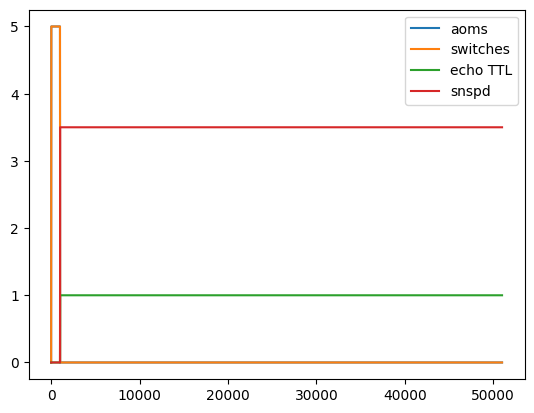

In [9]:
# 1ms excitation, 50ms counts
exhp.set_up_echo_SNSPD(awg, 0, 1e3, 1, countFor = 50e3, switchPreDelay = 0, plotting = True)


In [ ]:
exhp.set_up_echo_SNSPD(awg, 0, 1e3, 1, countFor = 50e3, switchPreDelay = 0, plotting = False)


In [ ]:
bias = -0.82

In [ ]:
exhp.set_detector(detectorOut, -0.82)

-0.82

In [13]:
exhp.reset_detector(detectorOut, 0)

0

In [14]:
exhp.all_on(awg, snspd = False, plotting = False)

All I can see is noise from the magnet PSU..

# Inhomogeneous Line Sweep with no B field
### Compare signal with vs. without dither and act accordingly
Wide motor scan. Then find peaks and centre on them - if not, then recourse to previous line centres.


### Wide Motor Scan
1500 - 1530 nm. Should take around 5 hours with these parameters.

Step size: 0.01 nm ~ 1.31 GHz
Estimated time for this many measurements: 5.0 hrs


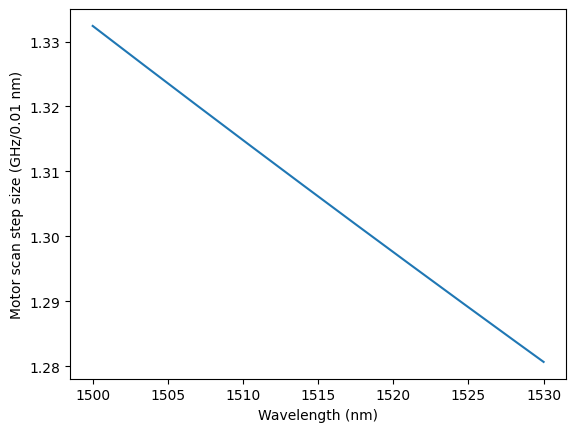

In [12]:
# Calculating the appropriate motor scan steps
c = 2.99792458e8 # [m/s]
stepSize = 0.01e-9 # [m] 0.001 nm minimum
topticaRange = np.array([1500, 1530])*1e-9 # [m]
topticaWavelengths = np.arange(topticaRange[0], topticaRange[1], stepSize)

freqRange = c/topticaWavelengths
freqSteps = freqRange/len(topticaWavelengths)

freqstepSizes = []
for i in range(len(freqSteps) - 1):
    freqstepSizes.append(np.abs(freqRange[i+1] - freqRange[i])/1e9)
print(fr'Step size: {stepSize * 1e9} nm ~ {np.mean(freqstepSizes) :.2f} GHz')

# Time estimates
numMeasurementsPerWL = 1                
intTime = 6 # [s]
wait = 0.5
print("Estimated time for this many measurements:", 
      np.round(len(topticaWavelengths) * numMeasurementsPerWL * intTime / 60 / 60, 2),         # [# steps] * [s of integration] * [# measurements] * [mins/s] * [hrs/min]
      "hrs")

plt.plot(topticaWavelengths[1:]*1e9, -np.diff(freqRange)/1e9)
plt.ylabel(f"Motor scan step size (GHz/{stepSize * 1e9} nm)")
plt.xlabel("Wavelength (nm)")
plt.show()

In [ ]:
# Excite for 1ms; count for 50ms
exhp.set_up_echo_SNSPD(0, 1e3, 1, countFor = 50e3, switchPreDelay = 0, plotting = True)

exhp.set_deadcycles(awg, 2, channels = [1, 2, 3, 4])

In [81]:
# Set savepaths
dateString = time.strftime('%Y-%m-%d')

pathData  = f'data/'+ dateString +f'/confocal_piezo_scan/'
pathPlots = f'plots/'+ dateString +f'/confocal_piezo_scan/'
os.makedirs(pathData, exist_ok = True)
os.makedirs(pathPlots, exist_ok = True)

In [ ]:
## 1500 - 1525 nm 
topticaRange = np.array([1500, 1530])*1e-9 # [m]
topticaWavelengths = np.arange(topticaRange[0], topticaRange[1], stepSize)

try:
    for wavelength in tqdm(topticaWavelengths, desc = f'Current wavelenght: {wavelength * 1e9} nm'):
        # Set laser frequency
        lhzz.set_laser_wavelength(laserIP, wavelength*1e9)
        
        # Collection parameters
        intTime = 6 # [s]
        bias = -0.82
        
        time.sleep(0.1)
        freq = exhp.get_laser_frequency(10) # [THz]
        exhp.reset_detector(bias, sleepTime = 0.01)
        
        data, times = exhp.getHistDataWrapped(intTime = intTime)      
        dataAndTime = np.array([times, data])

        # Save data
        now = datetime.datetime.now()
        filename = now.strftime("%Y-%m-%d %H-%M-%S") + "_freq_" + str(np.round(freq*1e3, 5)) +"_GHz_wl_" + str(np.round(wl*1e9, 4)) + "_nm"
        np.savetxt(pathData + filename + ".csv", dataAndTime, delimiter = ",")

        # Plot data
        fig, ax = plt.subplots()
        ax.plot(times*1e3, data)
        ax.set_xlabel("Time (ms)")
        ax.set_ylabel(f"Counts ({int} s integration)")
        ax.set_title(str(np.round(freq*1e3, 3)) +" GHz" + str(np.round(wl*1e9, 4)) + "_nm")
        fig.savefig(pathPlots + filename + ".png")
        fig.savefig(pathPlots + filename + ".eps")
        plt.close(fig)

    print("Finished succesfully!")
    print("Now turning laser off...")
    lhzz.turn_laser_off(laserIP)
    print("Laser off")

except Exception as error:
    print("Unexpected error occurred at wavelength", np.round(wavelength*1e9, 3), "nm, measured frequency was", np.round(freq, 5), " THz")
    print("-------------------")
    print(error)
    print("-------------------")
    print("Now turning laser off...")
    lhzz.turn_laser_off(laserIP)
    print("Laser off")

### Individual sites

In [ ]:
# Adjust scan centres according to motor scan
centreWavelengths = np.array([1521.3308401, 
                        1518.08, 
                        1514.70, 
                        1512.10873212, 
                        1508.2256587 , 
                        1506.976, 
                        1504.59024])

# Add theoretical location of lines
lines = [199.242e6, # Cubic Z1-Y2
        198.927e6, # Cubic Z1-Y1  
        198.76215e6, # B Z1-Y1
        198.2567e6, # G1 Z1-Y2
        197.913e6, # A Z1-Y2
        197.4686e6, # G1 Z1-Y1
        197.05e6] # A Z1-Y1  

lines_label = [r'Cubic:$Z_1 \rightarrow Y_2$',
               r'Cubic:$Z_1 \rightarrow Y_1$',
               r'B:$Z_1 \rightarrow Y_1$',
               r'G1:$Z_1 \rightarrow Y_2$',
               r'A:$Z_1 \rightarrow Y_2$',
               r'G1:$Z_1 \rightarrow Y_1$',
               r'A:$Z_1 \rightarrow Y_1$']

In [ ]:
# Set savepaths
dateString = time.strftime('%Y-%m-%d')

pathData  = f'data/'+ dateString +f'/confocal_site_scan/'
pathPlots = f'plots/'+ dateString +f'/confocal_site_scan/'
os.makedirs(pathData, exist_ok = True)
os.makedirs(pathPlots, exist_ok = True)

In [ ]:
for wavelength in centreWavelengths:
    # change laser wavelength
    lhzz.set_laser_wavelength(laserIP, wavelength)

    subFolderData = pathData +"/"+str(round(wavelength,5))+"/"    # don't forget ending "/"
    subFolderPlots = pathPlots +"/"+str(round(wavelength,5))+"/"
    os.makedirs(subFolderData, exist_ok=True)
    os.makedirs(subFolderPlots, exist_ok=True)

    scanHalf = 70       # [V]
    n = 140
    lineCentre = 70
    lhzz.set_piezo_center(laserIP, lineCentre)
    time.sleep(0.1)
    centrepV =lhzz.get_piezo_center(laserIP)
    pVs = np.linspace(-scanHalf, scanHalf, n) + centrepV
    intTime = 60
    bias = -0.82

    for i, pV in enumerate(pVs):
        lhzz.set_piezo_center(laserIP, pV)
        time.sleep(0.1)
        freq = exhp.get_laser_frequency(10)       # [THz]
        exhp.reset_detector(bias, sleepTime = 0.01)
        data, times = exhp.getHistDataWrapped(intTime=intTime)      

        dataAndTime = np.array([times, data])

        # save data
        now = datetime.datetime.now()
        filename = now.strftime("%Y-%m-%d %H-%M-%S") + "_freq_" + str(np.round(freq*1e6)) +"_MHz_pV_" + str(np.round(pV, 1)) + "_V"
        np.savetxt(subFolderData+filename + ".csv", dataAndTime, delimiter=",")

        # plot data
        fig, ax = plt.subplots()
        ax.plot(times*1e3, data)
        ax.set_xlabel("Time (ms)")
        ax.set_ylabel(f"Counts ({int} s integration)")
        ax.set_title(str(np.round(freq*1e3, 3)) +" GHz")
        fig.savefig(subFolderPlots + filename + ".png")
        fig.savefig(subFolderPlots + filename + ".eps")
        plt.close(fig)

        print("Finished pV = ", pV)

# Inhomogeneous Line Sweep with B field
Keep current below 20A - Mango is connected to series join with no dump resistor.
Same code as above but include magnet ramp.

# Holeburning
Adapt John's nanoparticle method.
